# 01. ISLES-2022 Dataset Exploration & Visualization (EDA)

**Project:** PBL6 - Ischemic Stroke Lesion Segmentation (ISLES 2022)  
**Goal:** Khám phá cấu trúc đa chuỗi xung MRI (DWI, ADC, FLAIR), đánh giá độ phân giải voxel spacing, và hiển thị trực quan vùng tổn thương não (Stroke Lesion) đè nhãn (Mask).

## 1. Thiết lập Môi trường & Đường dẫn (Dynamic Paths)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị đồ thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

# Định vị PROJECT_ROOT động (dù chạy trong notebooks hay root)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw' / 'ISLES-2022'
STATS_CSV = PROJECT_ROOT / 'results' / 'reports' / 'dataset_statistics.csv'

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset raw:  {DATA_RAW} (Exists: {DATA_RAW.exists()})")
print(f"Stats CSV:    {STATS_CSV} (Exists: {STATS_CSV.exists()})")

Project root: d:\03_University\Semester_7\PBL6
Dataset raw:  d:\03_University\Semester_7\PBL6\data\raw\ISLES-2022 (Exists: True)
Stats CSV:    d:\03_University\Semester_7\PBL6\results\reports\dataset_statistics.csv (Exists: True)


## 2. Phân tích Số liệu Thống kê Toàn bộ Dataset (Global EDA)

Đọc file `dataset_statistics.csv` vừa tạo từ `scripts/inspect_dataset.py` để đánh giá sự phân bố của 250 bệnh nhân.

In [2]:
df = pd.read_csv(STATS_CSV)
df.head()

,case,file,path,shape,dim_x,dim_y,depth_z,spacing_x,spacing_y,spacing_z
0,sub-strokecase0001,sub-strokecase0001_ses-0001_msk.nii.gz,data\raw\ISLES-2022\derivatives\sub-strokecase...,"(112, 112, 73)",112,112,73,2.0,2.0,2.0
1,sub-strokecase0002,sub-strokecase0002_ses-0001_msk.nii.gz,data\raw\ISLES-2022\derivatives\sub-strokecase...,"(112, 112, 72)",112,112,72,2.0,2.0,2.0
2,sub-strokecase0003,sub-strokecase0003_ses-0001_msk.nii.gz,data\raw\ISLES-2022\derivatives\sub-strokecase...,"(112, 112, 72)",112,112,72,2.0,2.0,2.0
3,sub-strokecase0004,sub-strokecase0004_ses-0001_msk.nii.gz,data\raw\ISLES-2022\derivatives\sub-strokecase...,"(112, 112, 72)",112,112,72,2.0,2.0,2.0
4,sub-strokecase0005,sub-strokecase0005_ses-0001_msk.nii.gz,data\raw\ISLES-2022\derivatives\sub-strokecase...,"(112, 112, 72)",112,112,72,2.0,2.0,2.0


In [3]:
# Trích xuất chuỗi xung (modality)
df['modality'] = df['file'].str.extract(r'_(dwi|adc|FLAIR|msk)\.nii\.gz')[0]
print("Số lượng từng chuỗi xung:")
print(df['modality'].value_counts())
print(f"\nTổng số ca bệnh nhân: {df['case'].nunique()}")

Số lượng từng chuỗi xung:
modality
msk      250
FLAIR    250
adc      250
dwi      250
Name: count, dtype: int64

Tổng số ca bệnh nhân: 250


### Phân bố Voxel Spacing (Độ phân giải không gian)
Biểu đồ bên dưới sẽ chứng minh: **Các ca bệnh có độ phân giải không gian (mm) rất khác nhau**.  
-> Đây là luận cứ quan trọng để đưa vào Báo cáo PBL6 giải thích tại sao bước **Resampling (Chuẩn hóa Spacing về 1.0mm hoặc 2.0mm)** là bắt buộc.

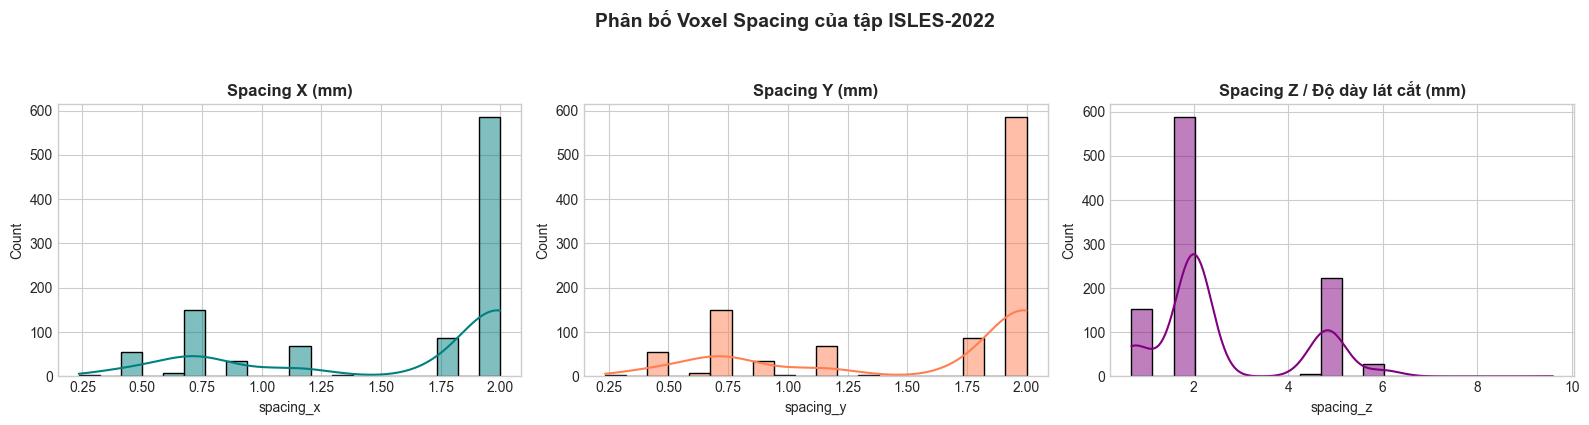

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['spacing_x'], ax=axes[0], color='teal', kde=True, bins=20)
axes[0].set_title('Spacing X (mm)', fontsize=12, fontweight='bold')

sns.histplot(df['spacing_y'], ax=axes[1], color='coral', kde=True, bins=20)
axes[1].set_title('Spacing Y (mm)', fontsize=12, fontweight='bold')

sns.histplot(df['spacing_z'], ax=axes[2], color='purple', kde=True, bins=20)
axes[2].set_title('Spacing Z / Độ dày lát cắt (mm)', fontsize=12, fontweight='bold')

plt.suptitle('Phân bố Voxel Spacing của tập ISLES-2022', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 3. Trực quan hóa một ca bệnh nhân cụ thể: `sub-strokecase0001`

Trong chẩn đoán đột quỵ nhồi máu não cấp tính:
- **DWI (Diffusion Weighted Imaging):** Vùng tế bào não bị chết do thiếu máu sẽ bị phù độc tế bào (cytotoxic edema), nước bị giữ lại làm tín hiệu **sáng rực (hyperintense)**.
- **ADC (Apparent Diffusion Coefficient):** Đối chiếu xem vùng đó có bị **tối đen (hypointense)** do hạn chế khuếch tán thực sự hay không (tránh hiện tượng giả tăng tín hiệu T2 shine-through).
- **FLAIR:** Cho cái nhìn giải phẫu tổng quát của toàn bộ mô não và dịch não tủy.
- **Mask:** Nhãn nhồi máu não do các chuyên gia y tế khoanh vùng (Ground Truth).

In [5]:
case_id = 'sub-strokecase0001'
ses_id = 'ses-0001'

case_dir = DATA_RAW / case_id / ses_id
deriv_dir = DATA_RAW / 'derivatives' / case_id / ses_id

# Đường dẫn 4 files
dwi_path = case_dir / 'dwi' / f"{case_id}_{ses_id}_dwi.nii.gz"
adc_path = case_dir / 'dwi' / f"{case_id}_{ses_id}_adc.nii.gz"
flair_path = case_dir / 'anat' / f"{case_id}_{ses_id}_FLAIR.nii.gz"
msk_path = deriv_dir / f"{case_id}_{ses_id}_msk.nii.gz"

# Đọc các khối thể tích NIfTI
dwi_img = nib.load(dwi_path)
adc_img = nib.load(adc_path)
flair_img = nib.load(flair_path)
msk_img = nib.load(msk_path)

dwi_data = dwi_img.get_fdata()
adc_data = adc_img.get_fdata()
flair_data = flair_img.get_fdata()
msk_data = msk_img.get_fdata()

print(f"DWI shape:   {dwi_data.shape}, Spacing: {dwi_img.header.get_zooms()[:3]}")
print(f"ADC shape:   {adc_data.shape}, Spacing: {adc_img.header.get_zooms()[:3]}")
print(f"FLAIR shape: {flair_data.shape}, Spacing: {flair_img.header.get_zooms()[:3]}")
print(f"Mask shape:  {msk_data.shape}, Labels duy nhất: {np.unique(msk_data)}")

DWI shape:   (112, 112, 73), Spacing: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
ADC shape:   (112, 112, 73), Spacing: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
FLAIR shape: (281, 352, 352), Spacing: (np.float32(0.71153224), np.float32(0.71022725), np.float32(0.71022725))
Mask shape:  (112, 112, 73), Labels duy nhất: [0. 1.]


### Tìm lát cắt (Slice) có diện tích tổn thương lớn nhất để soi rõ

In [6]:
# Đếm số lượng voxel tổn thương trên từng lát cắt dọc theo trục Z
slice_lesion_counts = np.sum(msk_data, axis=(0, 1))
best_slice_idx = int(np.argmax(slice_lesion_counts))

print(f"Tổng số lát cắt có chứa tổn thương: {np.count_nonzero(slice_lesion_counts)} / {msk_data.shape[2]}")
print(f"Lát cắt chứa ổ nhồi máu lớn nhất: Slice #{best_slice_idx} (Chứa {int(slice_lesion_counts[best_slice_idx])} voxels)")

Tổng số lát cắt có chứa tổn thương: 45 / 73
Lát cắt chứa ổ nhồi máu lớn nhất: Slice #44 (Chứa 54 voxels)


### Hiển thị Trực quan Song song Đa chuỗi xung & Đè Mask

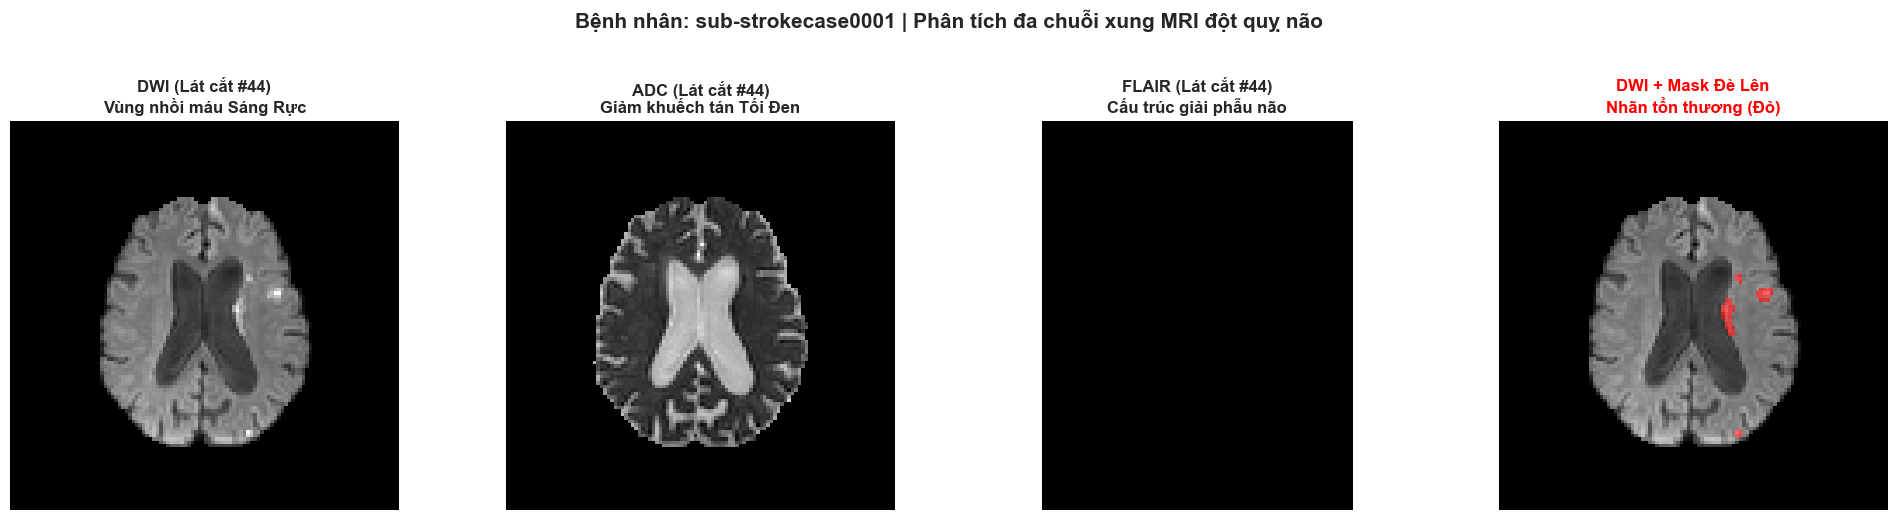

In [7]:
# Cắt lát 2D tại vị trí best_slice_idx
# Xoay 90 độ để đúng quy chuẩn hướng nhìn X-quang / MRI y tế (Radiological orientation)
slice_dwi = np.rot90(dwi_data[:, :, best_slice_idx])
slice_adc = np.rot90(adc_data[:, :, best_slice_idx])
slice_flair = np.rot90(flair_data[:, :, min(best_slice_idx, flair_data.shape[2] - 1)])
slice_msk = np.rot90(msk_data[:, :, best_slice_idx])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Chuỗi xung DWI
axes[0].imshow(slice_dwi, cmap='gray')
axes[0].set_title(f"DWI (Lát cắt #{best_slice_idx})\nVùng nhồi máu Sáng Rực", fontsize=12, fontweight='bold')
axes[0].axis('off')

# 2. Chuỗi xung ADC
axes[1].imshow(slice_adc, cmap='gray')
axes[1].set_title(f"ADC (Lát cắt #{best_slice_idx})\nGiảm khuếch tán Tối Đen", fontsize=12, fontweight='bold')
axes[1].axis('off')

# 3. Chuỗi xung FLAIR
axes[2].imshow(slice_flair, cmap='gray')
axes[2].set_title(f"FLAIR (Lát cắt #{best_slice_idx})\nCấu trúc giải phẫu não", fontsize=12, fontweight='bold')
axes[2].axis('off')

# 4. Đè Mask lên DWI
axes[3].imshow(slice_dwi, cmap='gray')
masked_overlay = np.ma.masked_where(slice_msk == 0, slice_msk)
axes[3].imshow(masked_overlay, cmap='autumn', alpha=0.6)
axes[3].set_title(f"DWI + Mask Đè Lên\nNhãn tổn thương (Đỏ)", fontsize=12, fontweight='bold', color='red')
axes[3].axis('off')

plt.suptitle(f"Bệnh nhân: {case_id} | Phân tích đa chuỗi xung MRI đột quỵ não", fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 4. Đo lường Thể tích Tổn thương & Vấn đề Mất cân bằng Lớp (Class Imbalance)

Trong bài toán y tế, tỷ lệ thể tích vùng bệnh so với toàn bộ não thường rất nhỏ. Hãy tính con số thực tế:

In [8]:
zooms = msk_img.header.get_zooms()[:3]
voxel_volume_mm3 = zooms[0] * zooms[1] * zooms[2]

total_voxels = msk_data.size
lesion_voxels = int(np.sum(msk_data))
lesion_percentage = (lesion_voxels / total_voxels) * 100
lesion_volume_ml = (lesion_voxels * voxel_volume_mm3) / 1000.0

print("=" * 65)
print(f"THỐNG KÊ THỂ TÍCH TỔN THƯƠNG: {case_id}")
print("=" * 65)
print(f"Kích thước 1 voxel:           {zooms[0]:.2f} x {zooms[1]:.2f} x {zooms[2]:.2f} mm")
print(f"Thể tích 1 voxel:             {voxel_volume_mm3:.2f} mm3")
print(f"Tổng số voxel của khối não:   {total_voxels:,}")
print(f"Số voxel bị đột quỵ:          {lesion_voxels:,}")
print(f"Tỷ lệ vùng tổn thương:        {lesion_percentage:.4f}%")
print(f"Thể tích ổ nhồi máu (Infarct): {lesion_volume_ml:.2f} mL (cm3)")
print("=" * 65)
print("\n-> KẾT LUẬN KIẾN TRÚC MÔ HÌNH:")
print("Vùng tổn thương chỉ chiếm < 1% toàn bộ khối não (cực kỳ mất cân bằng).")
print("Bắt buộc phải áp dụng: Dice Loss, Focal Loss và Patch-based training (MONAI)!")

THỐNG KÊ THỂ TÍCH TỔN THƯƠNG: sub-strokecase0001
Kích thước 1 voxel:           2.00 x 2.00 x 2.00 mm
Thể tích 1 voxel:             8.00 mm3
Tổng số voxel của khối não:   915,712
Số voxel bị đột quỵ:          835
Tỷ lệ vùng tổn thương:        0.0912%
Thể tích ổ nhồi máu (Infarct): 6.68 mL (cm3)

-> KẾT LUẬN KIẾN TRÚC MÔ HÌNH:
Vùng tổn thương chỉ chiếm < 1% toàn bộ khối não (cực kỳ mất cân bằng).
Bắt buộc phải áp dụng: Dice Loss, Focal Loss và Patch-based training (MONAI)!
